In [ ]:
%load_ext autoreload
%autoreload 2

# Rules :
### Safer to run this notebook on colab, I didn't test on other servor
### This notebook has to be at the same tree level than the Graph_neural_network repo
### You need to restart after running the cell below

In [1]:
########## INSTALL TORCH GEOMETRIC ##################
# https://pytorch-geometric.readthedocs.io/en/latest/
#####################################################
import torch


def format_pytorch_version(version):
    return version.split("+")[0]


TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)


def format_cuda_version(version):
    return "cu" + version.replace(".", "")


CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)

!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 # downgrade pytorch
!pip install torch-geometric pyg-lib torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.5.0+cu121.html

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 81.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 58.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 99.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1

Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 128.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 130.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.1 MB/s eta 0:00:00


KeyboardInterrupt: 

In [1]:
#####################################################
################## PACKAGES #########################
#####################################################
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch_geometric.nn as graphnn
from sklearn.metrics import f1_score
from torch_geometric.datasets import PPI
from torch_geometric.loader import DataLoader

In [2]:
!git clone https://github.com/Camel-glitch/Graph_neural_network.git


Cloning into 'Graph_neural_network'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 29 (delta 14), reused 20 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 35.56 KiB | 535.00 KiB/s, done.
Resolving deltas: 100% (14/14), done.


In [3]:
!pwd

/content


In [4]:
!cd Graph_neural_network && git pull

Already up to date.


### Dataset

We use the Protein-Protein Interaction (PPI) network dataset which includes:
- 20 graphs for training
- 2 graphs for validation
- 2 graphs for testing

One graph of the PPI dataset has on average 2372 nodes. Each node has:
- 50 features : positional gene sets / motif gene / immunological signatures ...
- 121 (binary) labels : gene ontology sets (way to classify gene products like proteins).


In [5]:
### LOAD DATASETS

BATCH_SIZE = 2
max_epochs = 200

# Train Dataset
train_dataset = PPI(root="", split="train")
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
# Val Dataset
val_dataset = PPI(root="", split="val")
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
# Test Dataset
test_dataset = PPI(root="", split="test")
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Number of features and classes
n_features, n_classes = train_dataset[0].x.shape[1], train_dataset[0].y.shape[1]

print("Number of samples in the train dataset: ", len(train_dataset))
print("Number of samples in the val dataset: ", len(test_dataset))
print("Number of samples in the test dataset: ", len(test_dataset))
print("Output of one sample from the train dataset: ", train_dataset[0])
print("Edge_index :")
print(train_dataset[0].edge_index)
print("Number of features per node: ", n_features)
print("Number of classes per node: ", n_classes)

Extracting ./ppi.zip
Processing...


Number of samples in the train dataset:  20
Number of samples in the val dataset:  2
Number of samples in the test dataset:  2
Output of one sample from the train dataset:  Data(x=[1767, 50], edge_index=[2, 32318], y=[1767, 121])
Edge_index :
tensor([[   0,    0,    0,  ..., 1744, 1745, 1749],
        [ 372, 1101,  766,  ..., 1745, 1744, 1739]])
Number of features per node:  50
Number of classes per node:  121


Done!


Here we define a very simple Graph Neural Network model which will be used as our baseline. This model consists of three graph convolutional layers (from https://arxiv.org/pdf/1609.02907.pdf). The first two layers computes 256 features, followed by an ELU activation function. The last layer is used for (multi-label) classification task, computing 121 features (for each node).

In [6]:
import Graph_neural_network.class_GCN as class_GCN
import Graph_neural_network.train   as train


In [7]:
import torch

In [8]:
### DEVICE GPU OR CPU : will select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice: ", device)


### DEFINE THE MODEL
model_GCN = class_GCN.BasicGraphModel(input_size=n_features, hidden_size=256, output_size=n_classes).to(
    device
)

### DEFINE LOSS FUNCTION
loss_fcn = nn.BCEWithLogitsLoss()

### DEFINE OPTIMIZER
optimizer = torch.optim.Adam(model_GCN.parameters(), lr=0.005)

### TRAIN THE MODEL
epoch_list, basic_model_scores = train.train(
    model_GCN,
    loss_fcn,
    device,
    optimizer,
    max_epochs,
    train_dataloader,
    val_dataloader,
)


Device:  cuda
Epoch 00001 | Loss: 0.6378
F1-Score: 0.3367
Epoch 00002 | Loss: 0.5824
Epoch 00003 | Loss: 0.5625
Epoch 00004 | Loss: 0.5562
Epoch 00005 | Loss: 0.5516
Epoch 00006 | Loss: 0.5458
F1-Score: 0.3540
Epoch 00007 | Loss: 0.5412
Epoch 00008 | Loss: 0.5373
Epoch 00009 | Loss: 0.5342
Epoch 00010 | Loss: 0.5316
Epoch 00011 | Loss: 0.5288
F1-Score: 0.4047
Epoch 00012 | Loss: 0.5261
Epoch 00013 | Loss: 0.5235
Epoch 00014 | Loss: 0.5211
Epoch 00015 | Loss: 0.5188
Epoch 00016 | Loss: 0.5163
F1-Score: 0.3899
Epoch 00017 | Loss: 0.5138
Epoch 00018 | Loss: 0.5113
Epoch 00019 | Loss: 0.5089
Epoch 00020 | Loss: 0.5066
Epoch 00021 | Loss: 0.5045
F1-Score: 0.4190
Epoch 00022 | Loss: 0.5024
Epoch 00023 | Loss: 0.5003
Epoch 00024 | Loss: 0.4983
Epoch 00025 | Loss: 0.4963
Epoch 00026 | Loss: 0.4944
F1-Score: 0.4319
Epoch 00027 | Loss: 0.4925
Epoch 00028 | Loss: 0.4907
Epoch 00029 | Loss: 0.4889
Epoch 00030 | Loss: 0.4872
Epoch 00031 | Loss: 0.4855
F1-Score: 0.4577
Epoch 00032 | Loss: 0.4838
Ep

GCN Model : F1-Score on the validation set: 0.6034


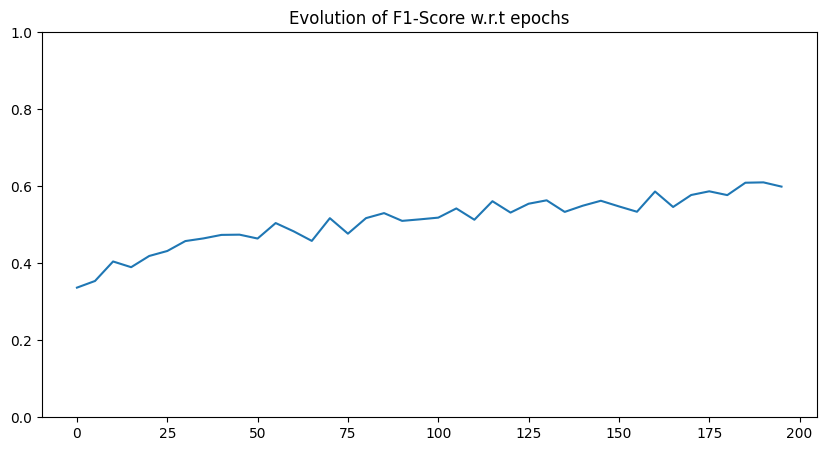

In [9]:

# Evaluate the model on the val set
### F1-SCORE ON VALID DATASET
score_valid = train.evaluate(model_GCN, device, val_dataloader)
print("GCN Model : F1-Score on the validation set: {:.4f}".format(score_valid))


### PLOT EVOLUTION OF F1-SCORE W.R.T EPOCHS
def plot_f1_score(epoch_list, scores):
    plt.figure(figsize=[10, 5])
    plt.plot(epoch_list, scores)
    plt.title("Evolution of F1-Score w.r.t epochs")
    plt.ylim([0.0, 1.0])
    plt.show()


plot_f1_score(epoch_list, basic_model_scores)

In [10]:
# Evaluate on the test set
print("Lancement de l'évaluation sur le jeu de test...")
test_f1 = train.evaluate(model_GCN, device, test_dataloader)

print(f"--- RÉSULTAT FINAL ---")
print(f"Test Micro-F1 Score : {test_f1:.4f}")

Lancement de l'évaluation sur le jeu de test...
--- RÉSULTAT FINAL ---
Test Micro-F1 Score : 0.6086


In [11]:
import Graph_neural_network.class_GAT as class_GAT
import torch.nn as nn
import torch.optim as optim

# 1. Instantiate the model
num_features = 50
model_GAT = class_GAT.InductiveGAT(nfeat=num_features, alpha=0.2)

# Move the model_GAT to the specified device (GPU if available)
model_GAT = model_GAT.to(device)

# 2. initialization working well(Xavier Uniform)
def glorot_init(m):
    """
    Initialize model weights using Glorot (Xavier) uniform initialization.
    """
    #If  nn.Linear was used
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight.data)
        if m.bias is not None:
            nn.init.zeros_(m.bias.data)

    # else nn.Parameter (ex: self.W, self.a)
    elif hasattr(m, 'W') and isinstance(m.W, nn.Parameter):
        nn.init.xavier_uniform_(m.W.data)
    elif hasattr(m, 'a') and isinstance(m.a, nn.Parameter):
        nn.init.xavier_uniform_(m.a.data)

# Initialize the model_GAT weights using the defined glorot_init function
model_GAT.apply(glorot_init)

# 3. Define the loss function and optimizer
optimizer = optim.Adam(model_GAT.parameters(), lr=0.005)

# Define the loss function (Binary Cross-Entropy Loss for multi-label classification)
criterion = nn.BCELoss()

### TRAIN THE model_GAT
epoch_list, model_GAT_scores = train.train(
    model_GAT,
    criterion,
    device,
    optimizer,
    max_epochs,
    train_dataloader,
    val_dataloader,
)

Epoch 00001 | Loss: 0.7368
F1-Score: 0.4127
Epoch 00002 | Loss: 0.5534
Epoch 00003 | Loss: 0.5385
Epoch 00004 | Loss: 0.5173
Epoch 00005 | Loss: 0.5039
Epoch 00006 | Loss: 0.4948
F1-Score: 0.5479
Epoch 00007 | Loss: 0.4810
Epoch 00008 | Loss: 0.4693
Epoch 00009 | Loss: 0.4586
Epoch 00010 | Loss: 0.4488
Epoch 00011 | Loss: 0.4391
F1-Score: 0.6037
Epoch 00012 | Loss: 0.4312
Epoch 00013 | Loss: 0.4227
Epoch 00014 | Loss: 0.4209
Epoch 00015 | Loss: 0.4199
Epoch 00016 | Loss: 0.4035
F1-Score: 0.6508
Epoch 00017 | Loss: 0.3927
Epoch 00018 | Loss: 0.3813
Epoch 00019 | Loss: 0.3716
Epoch 00020 | Loss: 0.3641
Epoch 00021 | Loss: 0.3598
F1-Score: 0.6913
Epoch 00022 | Loss: 0.3540
Epoch 00023 | Loss: 0.3514
Epoch 00024 | Loss: 0.3483
Epoch 00025 | Loss: 0.3426
Epoch 00026 | Loss: 0.3315
F1-Score: 0.7380
Epoch 00027 | Loss: 0.3239
Epoch 00028 | Loss: 0.3176
Epoch 00029 | Loss: 0.3101
Epoch 00030 | Loss: 0.3053
Epoch 00031 | Loss: 0.3054
F1-Score: 0.7533
Epoch 00032 | Loss: 0.3113
Epoch 00033 | Los

Basic Model : F1-Score on the validation set: 0.9056


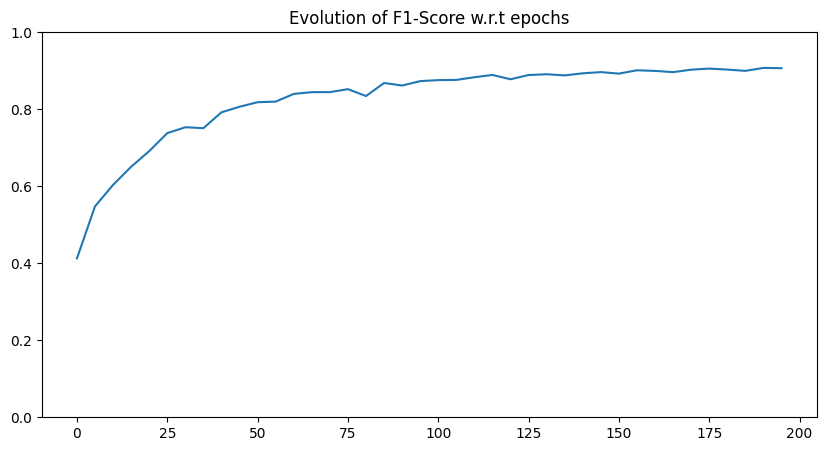

In [12]:
### F1-SCORE ON VALID DATASET
score_valid = train.evaluate(model_GAT, device, val_dataloader)
print("Basic Model : F1-Score on the validation set: {:.4f}".format(score_valid))


### PLOT EVOLUTION OF F1-SCORE W.R.T EPOCHS
def plot_f1_score(epoch_list, scores):
    plt.figure(figsize=[10, 5])
    plt.plot(epoch_list, scores)
    plt.title("Evolution of F1-Score w.r.t epochs")
    plt.ylim([0.0, 1.0])
    plt.show()


plot_f1_score(epoch_list, model_GAT_scores)

In [13]:
# Evaluate on the test set
print("Lancement de l'évaluation sur le jeu de test...")
test_f1 = train.evaluate(model_GAT, device, test_dataloader)

print(f"--- RÉSULTAT FINAL ---")
print(f"Test Micro-F1 Score : {test_f1:.4f}")

Lancement de l'évaluation sur le jeu de test...
--- RÉSULTAT FINAL ---
Test Micro-F1 Score : 0.9272


In [14]:
#SAVE locally
import torch

local_weights_path = "GAT_weights.pth"

# Sauvegarde des poids (state_dict)
torch.save(model_GAT.state_dict(), local_weights_path)

print(f"✅ Modèle sauvegardé localement : {local_weights_path}")

✅ Modèle sauvegardé localement : GAT_weights.pth
